In [2]:
import pandas as pd
df = pd.read_csv("C:\\Users\\vpaidmarri\\Desktop\\DS\\DataSets\\hr_employee_attrition.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
# Convert Object to Category

In [6]:
cat_cols = []

for cols in df.select_dtypes("object"):
    cat_cols.append(cols)
cat_cols

['Attrition',
 'BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'Over18',
 'OverTime']

In [7]:
df[cat_cols] = df[cat_cols].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   category
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   category
 8   EmployeeCount             1470 non-null   int64   
 9   EmployeeNumber            1470 non-null   int64   
 10  EnvironmentSatisfaction   1470 non-null   int64   
 11  Gender                    1470 non-null   category
 12  HourlyRate                1470 non-null   int64   
 13  JobInvolvement            1470 non-null   int64 

In [9]:
# Check for null

In [8]:
df.isna().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

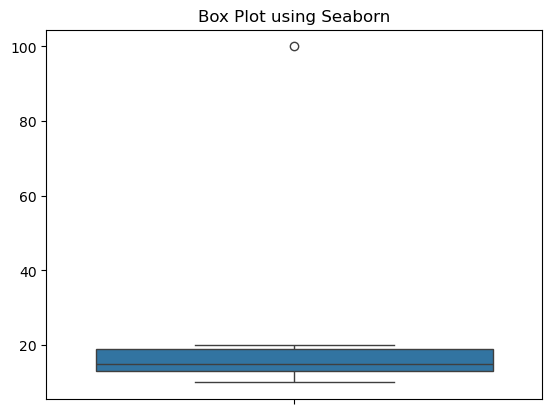

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

data = [10, 12, 14, 15, 18, 20, 100]

sns.boxplot(y=data)
plt.title("Box Plot using Seaborn")

plt.show()

In [18]:
# Box Plot
# draw a box plot to do the exploratory data analysis , with Attritation Target variable

In [11]:
num_cols = []
for cols in df.select_dtypes(["int64",'float64']):
    num_cols.append(cols)

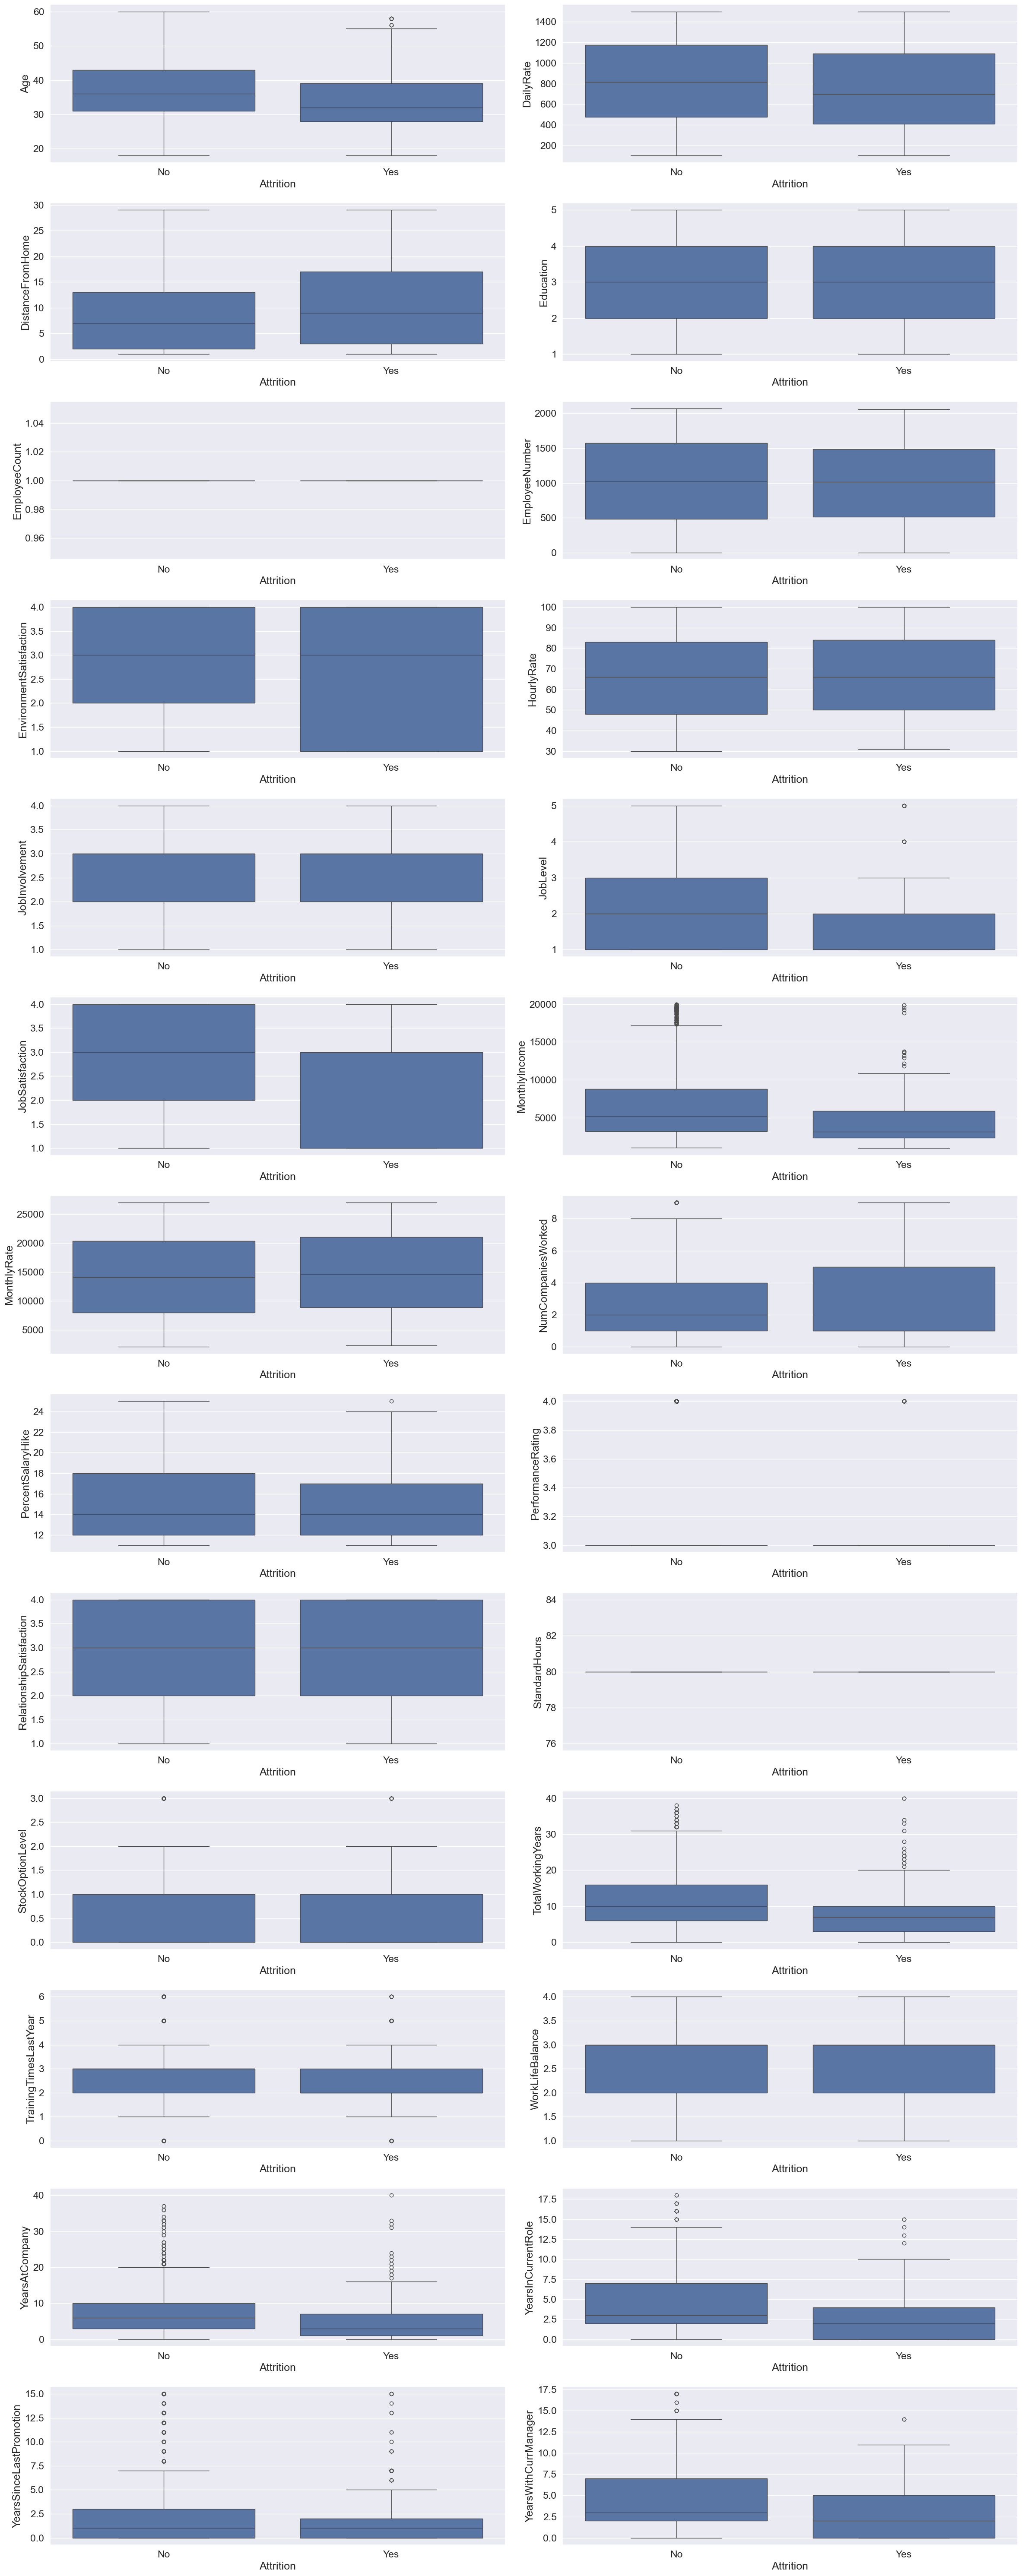

In [17]:
sns.set(font_scale=1.5)
fig = plt.figure(figsize=(24,60))
i=1
for column in df[num_cols]:
    plt.subplot(13,2,i)
    sns.boxplot(x=df['Attrition'],y=df.loc[:,column])
    i = i + 1
    
plt.tight_layout()
plt.show()

In [29]:
def bivariate_cat(data,col1,col2,rot):
    cross_tab = pd.crosstab(data[col1], data[col2]).apply(lambda x: x/x.sum() * 100, axis=1).round(2)
    print(cross_tab)
    ct_attr = cross_tab['Yes'].sort_values(ascending=False)
    ct_attr.plot.bar(figsize=(8,5))
    plt.xlabel('{}'.format(col1))
    plt.ylabel('% of attrition among employees'.format(col1))
    plt.title('{} Vs attrition rate'.format(col1))
    plt.xticks(rotation=rot)
    plt.show()
    return ct_attr

Attrition             No    Yes
PerformanceRating              
3                  83.92  16.08
4                  83.63  16.37


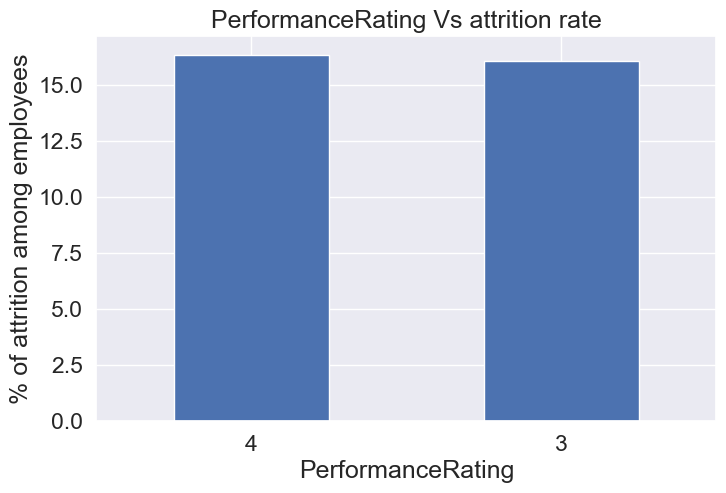

PerformanceRating
4    16.37
3    16.08
Name: Yes, dtype: float64

In [30]:
bivariate_cat(df, "PerformanceRating","Attrition",0)

Attrition     No    Yes
Education              
1          81.76  18.24
2          84.40  15.60
3          82.69  17.31
4          85.43  14.57
5          89.58  10.42


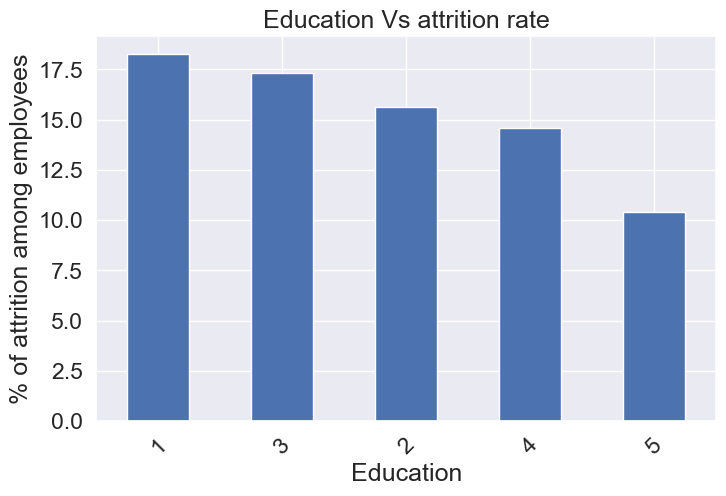

Education
1    18.24
3    17.31
2    15.60
4    14.57
5    10.42
Name: Yes, dtype: float64

In [32]:
bivariate_cat(df,'Education','Attrition',45 )

In [40]:
#Chi square test to reject the Null hypothesis, the lowest the p-vlaue the strongest you rject Null hypothesis

In [41]:
# Linear Algebra
import numpy as np
from scipy.stats import chi2_contingency


In [42]:
chi2, p_values = [], []
for f in cat_cols: 
    print(pd.
    chitest = chi2_contingency(pd.crosstab(df[f], df['Attrition']))
    p_values.append(np.round(chitest[1],3))

chi_results = pd.DataFrame(p_values, index = cat_cols)
chi_results

,0
Attrition,0.000
BusinessTravel,0.000
Department,0.005
EducationField,0.007
Gender,0.291
JobRole,0.000
MaritalStatus,0.000
Over18,1.000
OverTime,0.000
